In [1]:
# ==================
# Imports and Setup
# ==================

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv("ph_clean.csv")

# Plot Style
PALETTE = {
    "acid": "#8B0000",       # red
    "neutral": "#2E7D32",    # green
    "alkaline": "#1E88E5",   # blue
    "sand": "#F5E6C4",
    "charcoal": "#2B2B2B"
}

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.facecolor": PALETTE["sand"],
    "figure.facecolor": PALETTE["sand"],
    "text.color": PALETTE["charcoal"]
})

# Classifier Colors
# Color Mapping
color_map = {
    "Acidic": "#8B0000",    # red
    "Neutral": "#2E7D32",   # green
    "Alkaline": "#1E88E5"   # blue
}

def clean_plot():
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



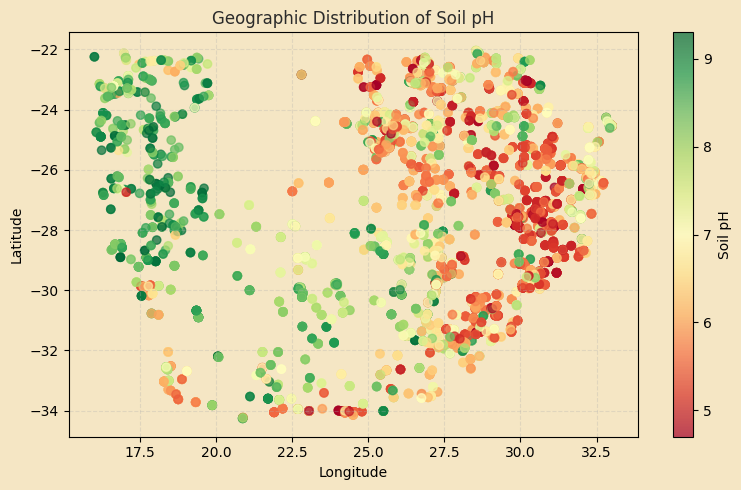

In [5]:
# Core pH Map

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['value_avg'],
    cmap='RdYlGn',  # red → yellow → green
    alpha=0.7
)

plt.colorbar(label="Soil pH")

plt.title("Geographic Distribution of Soil pH")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

clean_plot()
plt.show()

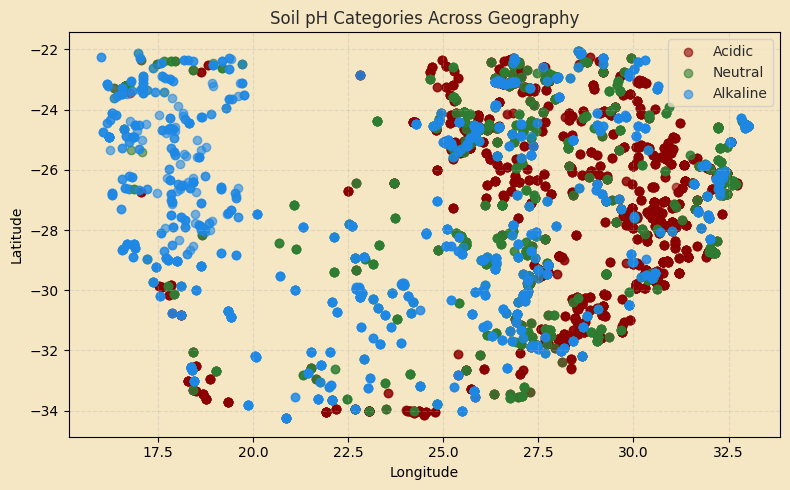

In [7]:
# Category Map

color_map = {
    "Acidic": PALETTE["acid"],
    "Neutral": PALETTE["neutral"],
    "Alkaline": PALETTE["alkaline"]
}

for category in ["Acidic", "Neutral", "Alkaline"]:
    subset = df[df['ph_category'] == category]
    
    plt.scatter(
        subset['longitude'],
        subset['latitude'],
        color=color_map[category],
        label=category,
        alpha=0.6
    )

plt.legend()

plt.title("Soil pH Categories Across Geography")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

clean_plot()
plt.show()

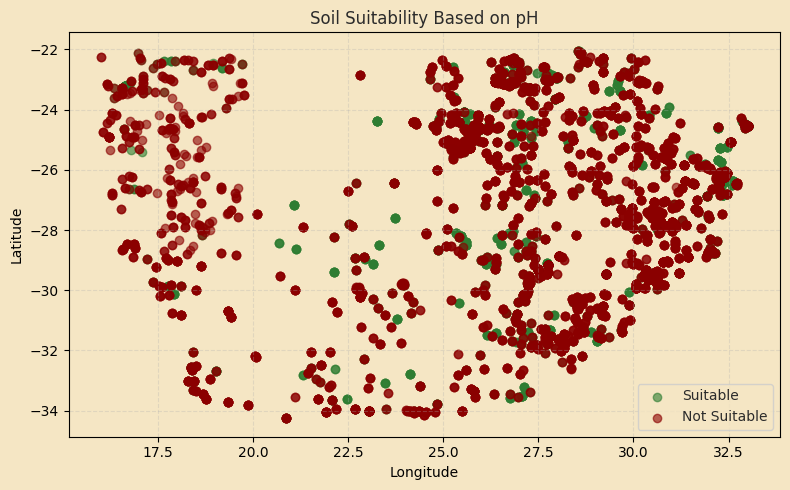

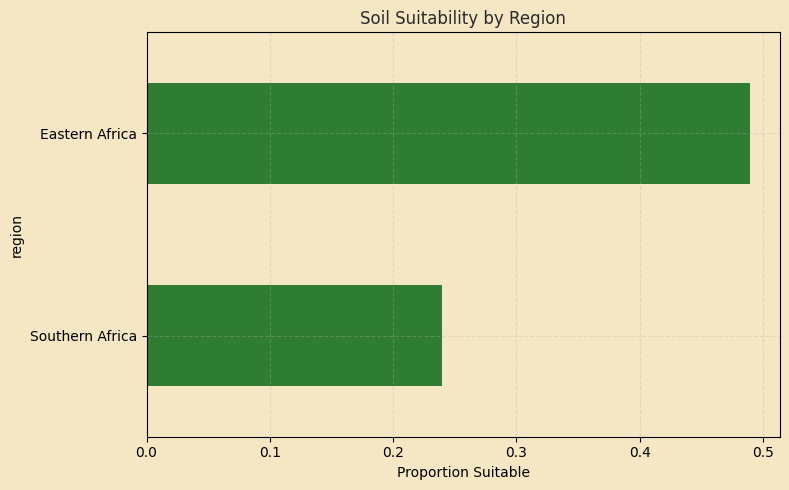

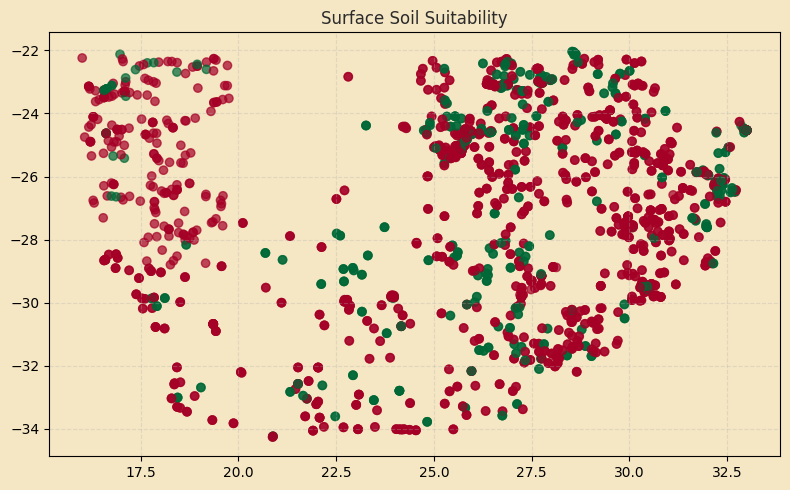

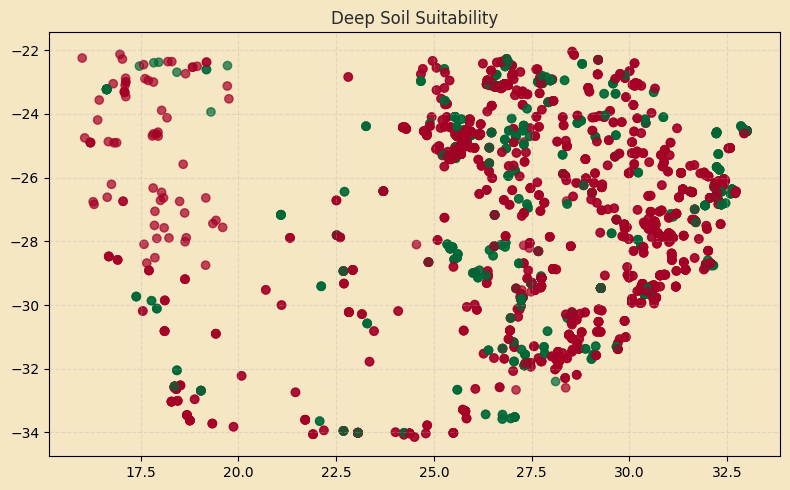

In [17]:
# =================
# Soil Suitability
# =================

# Soil Suitability Map
# Define Suitability
df['is_suitable'] = df['value_avg'].between(6.5, 7.5)

colors = {
    True: PALETTE["neutral"],
    False: PALETTE["acid"]
}

for val in [True, False]:
    subset = df[df['is_suitable'] == val]
    
    plt.scatter(
        subset['longitude'],
        subset['latitude'],
        color=colors[val],
        label="Suitable" if val else "Not Suitable",
        alpha=0.6
    )

plt.legend()

plt.title("Soil Suitability Based on pH")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

clean_plot()
plt.show()

# Regional Suitability Score
region_suitability = df.groupby('region')['is_suitable'].mean().sort_values()

region_suitability.plot(
    kind='barh',
    color=PALETTE["neutral"]
)

plt.title("Soil Suitability by Region")
plt.xlabel("Proportion Suitable")

clean_plot()
plt.show()

# Surface vs. Depth Suitability
# Depth Definition
surface = df[df['depth_category'] == "Surface"]
deep = df[df['depth_category'] == "Deep"]

# Surface Map
plt.scatter(
    surface['longitude'],
    surface['latitude'],
    c=surface['is_suitable'],
    cmap='RdYlGn',
    alpha=0.7
)

plt.title("Surface Soil Suitability")

clean_plot()
plt.show()

# Deep Map
plt.scatter(
    deep['longitude'],
    deep['latitude'],
    c=deep['is_suitable'],
    cmap='RdYlGn',
    alpha=0.7
)

plt.title("Deep Soil Suitability")

clean_plot()
plt.show()

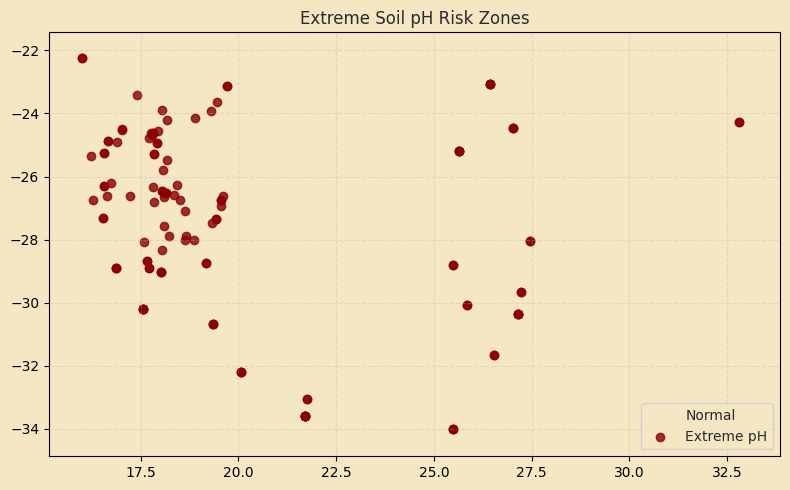

In [23]:
# Risk Zones
# Define Extremes
df['extreme'] = (df['value_avg'] < 4) | (df['value_avg'] > 9)

# Risk Plot
plt.scatter(
    df['longitude'],
    df['latitude'],
    color=PALETTE["sand"],
    alpha=0.3,
    label="Normal"
)

extreme = df[df['extreme']]

plt.scatter(
    extreme['longitude'],
    extreme['latitude'],
    color=PALETTE["acid"],
    alpha=0.8,
    label="Extreme pH"
)

plt.legend()

plt.title("Extreme Soil pH Risk Zones")

clean_plot()
plt.show()